In [1]:
#simulare con Monte Carlo (Metropolis) una particella soggetta ad un Potenziale Double Well 
#in D dimensioni a contatto termico con un reservoir a temperatura T.
import jax 
import jax.numpy as jnp
import matplotlib.pyplot as plt
import functools

In [2]:
#definiamo il potenziale in modo che x1 sia la variabile lenta e x2,...,xD siano le variabili veloci
@jax.jit
def V(x, a=2.0, b=1.0):
    return a * (x[0]**2 - b)**2 + 0.5 * jnp.sum(x[1:]**2)

In [3]:
#genera una configurazione iniziale casuale usando una gaussiana standard
@functools.partial(jax.jit, static_argnums=(1,))
def generate_config(key, D):
    key, subkey = jax.random.split(key)
    x = jax.random.normal(subkey, shape=(D,))
    return x, key

In [4]:
#genera un numero casuale con una gaussiana standard D dim (per eta: rumore termico)
@functools.partial(jax.jit, static_argnums=(1,))
def generate_normal(key,D):
    key, subkey = jax.random.split(key)
    x = jax.random.normal(subkey, shape=(D,))
    return x, key

#da uniforme:
@jax.jit
def generate_uniform(key):
    key, subkey = jax.random.split(key)
    x = jax.random.uniform(subkey)
    return x, key

In [5]:
#funzione di accettazione di Metropolis
@jax.jit
def metropolis_acceptance(delta_E, T):
    A = jnp.where(delta_E <= 0, 1.0, jnp.exp(-delta_E / T))
    return A

#funzione per eseguire un passo di Metropolis
@jax.jit
def metropolis_step(x, key, T, step_size=0.1):
    D = x.shape[0]
    # nuova configurazione proposta
    eta, key = generate_normal(key,D)
    x_proposed = x + step_size * eta
    # calcola la differenza di energia
    delta_E = V(x_proposed) - V(x)
    # accetta o rifiuta la nuova configurazione
    accept_prob = metropolis_acceptance(delta_E, T)
    u, key = generate_uniform(key)
    accept = u < accept_prob
    x_new = jnp.where(accept, x_proposed, x)
    return x_new, key, accept

In [6]:
#funzione per eseguire la simulazione
@functools.partial(jax.jit, static_argnums=(1, 3, 5))
def run_simulation(key, D, T, n_steps, step_size=0.1, initial_config="random"):
    x, key = generate_config(key, D)
    if initial_config == "zeros":
        x = jnp.zeros(D)
    if initial_config == "ones":
        x = jnp.ones(D)
    if initial_config == "-ones":
        x = jnp.ones(D) *(-1)

    def body(carry, _):
        x, key, acc = carry
        x, key, accepted = metropolis_step(x, key, T, step_size)
        return (x, key, acc + accepted), x

    (_, _, acceptances), trajectory = jax.lax.scan(
        body, (x, key, 0), None, length=n_steps
    )
    return trajectory, acceptances / n_steps

Acceptance rate: 0.85


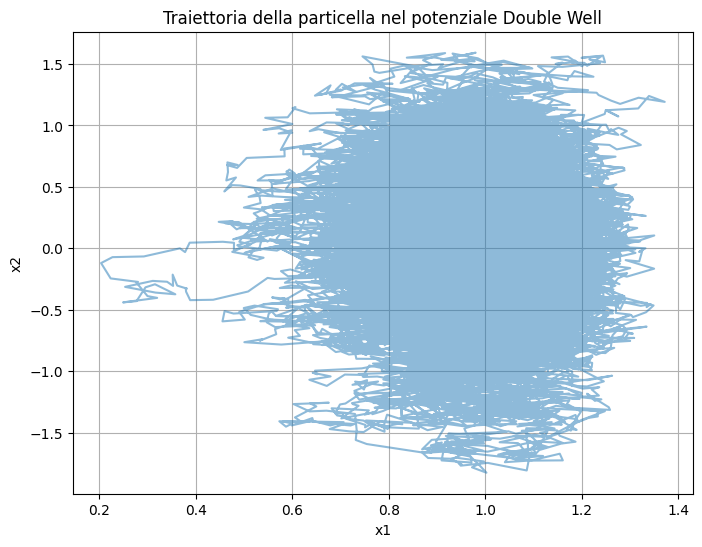

In [7]:
#parametri della simulazione
D = 2  # dimensioni
T = 0.2  # temperatura
n_steps = 70000  # numero di passi
step_size = 0.05  # dimensione del passo

#la simulazione
key = jax.random.PRNGKey(0)
trajectory, acceptance_rate = run_simulation(key, D, T, n_steps, step_size, "ones")
print(f"Acceptance rate: {acceptance_rate:.2f}")

#visualizzazione della traiettoria    
plt.figure(figsize=(8, 6))
plt.plot(trajectory[:, 0], trajectory[:, 1], alpha=0.5)
plt.title("Traiettoria della particella nel potenziale Double Well")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.show()


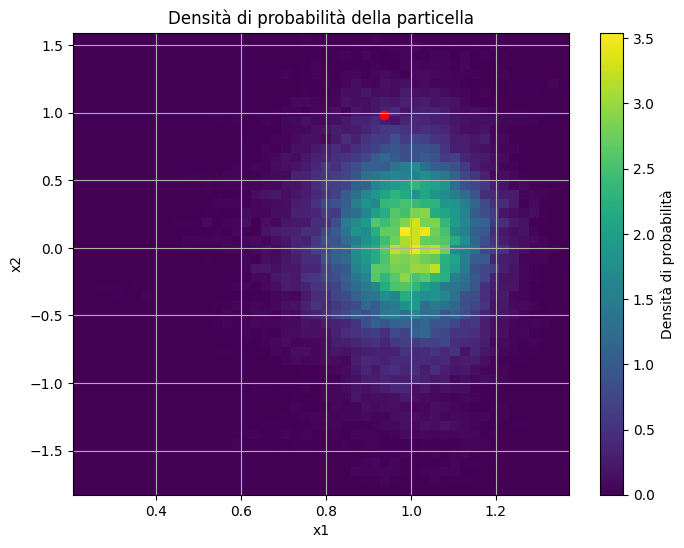

In [8]:
#plot delle zone più visitate dalla particella:
plt.figure(figsize=(8, 6))
plt.hist2d(trajectory[:, 0], trajectory[:, 1], bins=50, density=True, cmap='viridis')
plt.title("Densità di probabilità della particella")
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(label='Densità di probabilità')
#plot della prima configurazione:
plt.scatter(trajectory[0, 0], trajectory[0, 1], color='red', label='Configurazione iniziale')
plt.grid()
plt.show()


In [9]:
#osservabili di interesse a fissata D: Energia media(T), Cv(T), tempo di correlazione(T)
def mean_energy(trajectory):
    energies = jax.vmap(V)(trajectory)
    return jnp.mean(energies)

def heat_capacity(trajectory, T):
    energies = jax.vmap(V)(trajectory)
    mean_E = jnp.mean(energies)
    mean_E2 = jnp.mean(energies**2)
    Cv = (mean_E2 - mean_E**2) / (T**2)
    return Cv

In [10]:
dimensions = [1,2, 5]
temperatures = jnp.linspace(0.001, 2, 30)
n_steps = 70000
step_size = 0.05

results = {}
for D in dimensions:
    results[D] = {
        "T": [],
        "E_mean": [],
        "Cv": [],
        "acceptance": []
    }

    for T in temperatures:
        key = jax.random.PRNGKey(0)

        trajectory, acceptance_rate = run_simulation(
            key, D, T, n_steps, step_size, "random")

        E_mean = mean_energy(trajectory)
        Cv = heat_capacity(trajectory, T)

        results[D]["T"].append(T)
        results[D]["E_mean"].append(E_mean)
        results[D]["Cv"].append(Cv)
        results[D]["acceptance"].append(acceptance_rate)

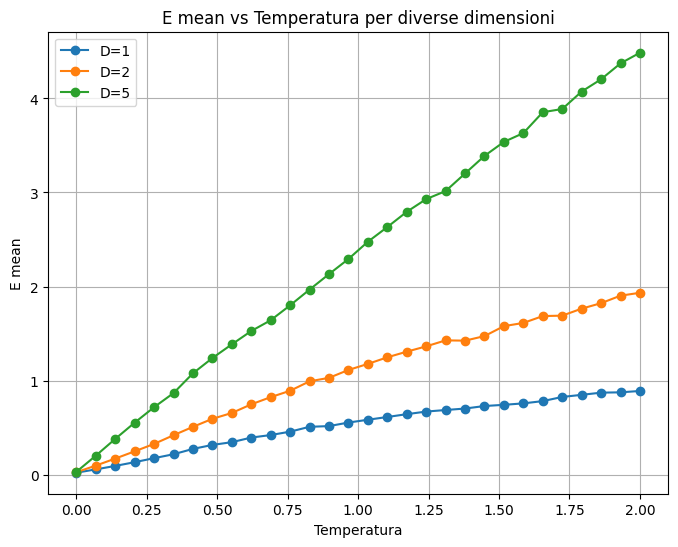

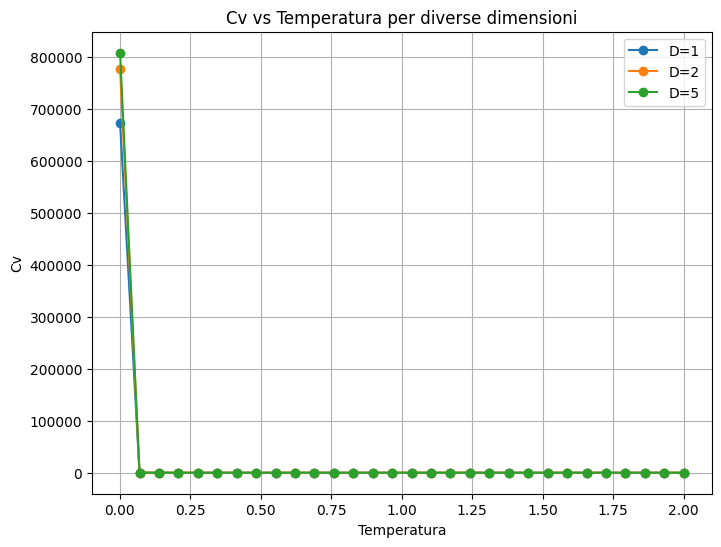

In [11]:
def plot_obs__D_T(results, dimensions, observable="E_mean"):
    plt.figure(figsize=(8,6))

    for D in dimensions:
        plt.plot(
            results[D]["T"],
            results[D][observable],
            marker='o',
            label=f"D={D}"
        )

    plt.xlabel("Temperatura")
    plt.ylabel(observable.replace('_', ' ').capitalize())
    plt.title(f"{observable.replace('_', ' ').capitalize()} vs Temperatura per diverse dimensioni")
    plt.legend()
    plt.grid()
    plt.show()

plot_obs__D_T(results, dimensions, "E_mean")
plot_obs__D_T(results, dimensions, "Cv")

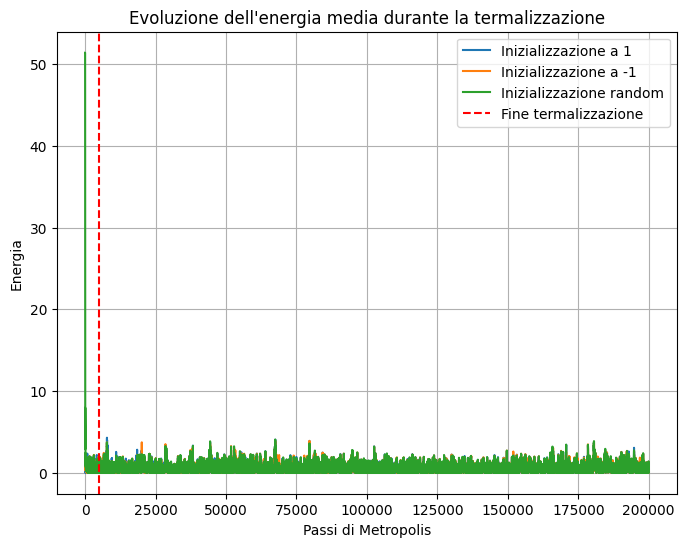

In [12]:
#termalizzazione: osserviamo come evolve l'energia media per due config. iniziali diverse
n_steps = 200000
D = 2
T = 0.4

key = jax.random.PRNGKey(0)
trajectory1, acceptance_rate1 = run_simulation(key, D, T, n_steps, step_size, "ones")

key = jax.random.PRNGKey(0)
trajectory_1, acceptance_rate_1 = run_simulation(key, D, T, n_steps, step_size, "-ones")

key = jax.random.PRNGKey(0)
trajectoryR, acceptance_rateR = run_simulation(key, D, T, n_steps, step_size, "random")

plt.figure(figsize=(8, 6))
plt.plot(jnp.arange(n_steps), jax.vmap(V)(trajectory1), label="Inizializzazione a 1")
plt.plot(jnp.arange(n_steps), jax.vmap(V)(trajectory_1), label="Inizializzazione a -1")
plt.plot(jnp.arange(n_steps), jax.vmap(V)(trajectoryR), label="Inizializzazione random")
# step per termalizzazione:
plt.axvline(x=5000, color='red', linestyle='--', label='Fine termalizzazione')
plt.xlabel("Passi di Metropolis")
plt.ylabel("Energia")
plt.title("Evoluzione dell'energia media durante la termalizzazione")
plt.legend()
plt.grid()
plt.show()


